# Preprocessing

::: {.callout-note title="Learning outcome"}

 We will answer to the following questions:

 -   How can I **import single-cell data** into R?
 -   How are different types of data/information (e.g. cell
     information, gene information, etc.) **stored and manipulated**?
 -   How can I obtain basic **summary metrics** for cells and genes and
     **filter the data** accordingly?
 -   How can I **visually explore** these metrics?

:::

We start by loading all the packages necessary for the analysis and
setup a few things

In [10]:
pacman::p_load('Seurat', 'parallel', 'multtest', 'metap', 'purrr', 'dplyr', 'stringr', 'tibble', 'ggplot2', 'MAST', 'WGCNA', 'hdWGCNA', 'patchwork', 'stringi')

In [39]:
source("../Scripts/script.R")

## Download data

We check if the data exists, otherwise a script will download the
missing data files in the appropriate folder, which should be `../Data`.

In [17]:
downloadData()

Data folder does not exists! Create one

Download ../Data/faba1.tar and unzip



Download ../Data/faba2.tar and unzip

Download ../Data/faba3.tar and unzip

Done!



## Import data

We import the data reading the matrix files aligned by STAR. Those are
usually contained in a folder with three files. One is in `mtx` format and contains the counts, the other two are in `tsv` format and contain the information about the genes and the cells, respectively. We will use the `Read10X` function from the `Seurat` package, which is designed to read this type of files.

In [18]:
mtx <- ReadMtx("../Data/faba1/UniqueAndMult-EM.mtx", 
                 "../Data/faba1/barcodes.tsv", 
                 "../Data/faba1/features.tsv")

::: {.callout-warning title="Preprocessing multiple datasets"}

 Note that we are loading only one dataset. The others will be used later - so
 **we will now focus on the preprocessing of a single dataset**. In
 general, when you have multiple datasets, you must preprocess them one
 at a time before integrating them together.

:::

What we obtain in the command above is an expression matrix. Look at the
first 10 rows and columns of the matrix (whose rows represent genes and
columns droplets/cells) - the dots are zeros (they are not stored in the
data, which has a compressed format called `dgCMatrix`), and **are the
majority of the expression values obtained in scRNA data!**

In [19]:
mtx[1:10,1:10]

  [[ suppressing 10 column names ‘AAAAAAAA’, ‘AAAAAACA’, ‘AAAAAACC’ ... ]]



10 x 10 sparse Matrix of class "dgCMatrix"
                                                    
Vfaba.Hedin2.R2.1g000001GeneNAME . . . . . . . . . .
Vfaba.Hedin2.R2.1g000002GeneNAME . . . . . . . . . .
Vfaba.Hedin2.R2.1g000003GeneNAME . . . . . . . . . .
Vfaba.Hedin2.R2.1g000004GeneNAME . . . . . . . . . .
Vfaba.Hedin2.R2.1g000005GeneNAME . . . . . . . . . .
Vfaba.Hedin2.R2.1g000006GeneNAME . . . . . . . . . .
Vfaba.Hedin2.R2.1g000007GeneNAME . . . . . . . . . .
Vfaba.Hedin2.R2.1g000008GeneNAME . . . . . . . . . .
Vfaba.Hedin2.R2.1g000009GeneNAME . . . . . . . . . .
Vfaba.Hedin2.R2.1g000010GeneNAME . . . . . . . . . .

What is the percentage of zeros in this matrix? You can see it for
yourself below - it is a lot, but quite surprisingly we can get a lot of
information from the data!

In [20]:
cat("Number of zeros: ")
zeros <-  sum(mtx==0)
cat( zeros )

Number of zeros: 552117953

In [21]:
cat("Number of expression entries: ")
total <- dim(mtx)[1] * dim(mtx)[2]
cat( total )

Number of expression entries: 552244104

In [23]:
cat("Percentage of zeros: ")
cat( zeros / total * 100 )

Percentage of zeros: 99.97716

## Create a single cell object in Seurat

We use our count matrix to create a Seurat object. A Seurat object
allows you to **store the count matrix** and future modifications of it
(for example its normalized version), together with **information
regarding cells and genes** (such as clusters of cell types) and their
**projections** (such as PCA and tSNE). We will go through these
elements, but first we create the object with `CreateSeuratObject`:

In [31]:
data <- CreateSeuratObject(counts = mtx, 
                            project = "samuele", 
                            min.cells = 3, 
                            min.features = 30)

dataMtx <- GetAssayData(data$RNA)

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message in GetAssayData.StdAssay(data$RNA):
“data layer is not found and counts layer is used”


When creating the object, we have alrteady specified some parameters, such as `min.cells` and `min.features`, which filter out genes and cells that are not expressed in a minimum number of cells, or that do not express a minimum number of genes, respectively. Those are some bare minimums for quality control, especially to remove cells without transcripts coming from some errouneous alignment, and genes that are not detected in any cell. 

The number of zeros and their percentage will also change

In [32]:
cat("Number of zeros: ")
zeros <-  sum(dataMtx==0)
cat( zeros )

Number of zeros: 1014175

In [34]:
cat("Number of expression entries: ")
total <- dim(dataMtx)[1] * dim(dataMtx)[2]
cat( total )

Number of expression entries: 1069926

In [35]:
cat("Percentage of zeros: ")
cat( zeros / total * 100 )

Percentage of zeros: 94.78927

The arguments of the command are \* `counts`: the count matrix \*
`project`: a project name \* `min.cells`: a minimum requirement for
genes, in our case saying they must be expressed in at least 3 cells. If
not, they are filtered out already now when creating the object. \*
`min.features`: a minimum requirement for cells. Cells having less than
200 expressed genes are removed from the beginning from the data.

Values for the minimum requirements chosen above are standard checks
when running the analysis. Droplets not satisfying those requirements
are of extremely bad quality and not worth carrying on during the
analysis (remember the knee plot).

How many genes and cells have been filtered out?

In [36]:
cat("Starting Genes and Cells:\n")
cat( dim(mtx) )

cat("\nFiltered Genes and Cells:\n")
cat( dim(mtx) - dim(data) )

cat("\nRemaining Genes and Cells:\n")
cat( dim(data) )

Starting Genes and Cells:
38543 14328
Filtered Genes and Cells:
36629 13769
Remaining Genes and Cells:
1914 559

### Content of a Seurat Object

:::{.callout-note title="Seurat object blog post"}
Before continuing in this notebook, it is a good idea to read about the Seurat object and its structure. There is an amazing post illustrating exactly that [at this webpage](https://biostatsquid.com/seurat-objects-explained/). On the same webpage you can find a video as well if you prefere that to reading.
:::

What is contained in the Seurat object? There are various *slots* that store different types of information. We can use the command `str` to list the various *slots* of the object. Each slot is accessible through the character `@`.

In [12]:
str(data, max.level = 2)

Formal class 'Seurat' [package "SeuratObject"] with 13 slots
  ..@ assays      :List of 1
  ..@ meta.data   :'data.frame':	559 obs. of  3 variables:
  ..@ active.assay: chr "RNA"
  ..@ active.ident: Factor w/ 1 level "samuele": 1 1 1 1 1 1 1 1 1 1 ...
  .. ..- attr(*, "names")= chr [1:559] "AAACAGGC" "AAAGCGGA" "AAAGGCTG" "AACACGCA" ...
  ..@ graphs      : list()
  ..@ neighbors   : list()
  ..@ reductions  : list()
  ..@ images      : list()
  ..@ project.name: chr "samuele"
  ..@ misc        : list()
  ..@ version     :Classes 'package_version', 'numeric_version'  hidden list of 1
  ..@ commands    : list()
  ..@ tools       : list()


The first slot is called `assays`. Each assay is related to part of the analysis and contains `layers`, which are expression matrices. Each matrix is collected during the analysis when, for example,
normalizing data or doing other transformations of it. Right now we only
have the `RNA` assay with the layer `counts` (expression from the alignment). 

In [13]:
data@assays

$RNA
Assay (v5) data with 1914 features for 559 cells
First 10 features:
 Vfaba.Hedin2.R2.1g000029GeneNAME, Vfaba.Hedin2.R2.1g000031GeneNAME,
Vfaba.Hedin2.R2.1g000041GeneNAME, Vfaba.Hedin2.R2.1g000079GeneNAME,
Vfaba.Hedin2.R2.1g000098GeneNAME, Vfaba.Hedin2.R2.1g000131GeneNAME,
Vfaba.Hedin2.R2.1g000144GeneNAME, Vfaba.Hedin2.R2.1g000194GeneNAME,
Vfaba.Hedin2.R2.1g000201GeneNAME, Vfaba.Hedin2.R2.1g000223GeneNAME 
Layers:
 counts 


The second slot is the one that contains the metadata for each cell. It
is easily visualized as a table (the command `glimpse` shows a description of the table):

In [37]:
glimpse( data@meta.data )

Rows: 559
Columns: 3
$ orig.ident   <fct> samuele, samuele, samuele, samuele, samuele, samuele, sam…
$ nCount_RNA   <dbl> 498.9999, 80.0000, 238.0000, 345.0000, 731.0000, 778.5000…
$ nFeature_RNA <int> 126, 32, 89, 120, 112, 145, 154, 198, 41, 67, 38, 97, 195…


The table contains a name for the dataset (`orig.ident`, useful to
distinguish multiple datasets when merged together), how many RNA transcripts
are contained in each cell (`nCount_RNA`), the number of expressed genes
in each cell (`nFeature_RNA`) and the sample name. More metadata can be added along the analysis, and some is
added automatically by Seurat when running specific commands.

The `assays` and `meta.data` slots are the most relevant and useful to
know - the other ones are mostly for internal use by Seurat and we do
not go into detail with those right now.

## Finding filtering criteria

We want to look in depth at which droplets do not contain good quality
data, so that we can filter them out. The standard approach - which
works quite well - is to study the **distribution of various quality
measures**. We will look at some plots and
decide some threshold, then we will apply them at the end after looking
at all the histograms.

#### Number of transcripts per cell

We plot a histogram of the number of transcripts per cell in
[Figure 7](#fig-rnacount) below. On the right, we zoom into the
histogram. We want to **filter out the cells with the lowest number of
transcripts** - often there is a peak we can identify with a group of
low-quality cells. Here we can choose to remove cells with less than
~700 transcripts (some people prefere to do a lighter filtering, and
would for example set a threshold to a lower value). We remove also
**cells with too many transcripts** that might contain some weird
transcripts - which is also helpful for normalization because it removes
some outlying values. For those we can set a limit to 30000, where there
is a very thin tail in the histogram.

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
Warning message:
“Removed 316 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


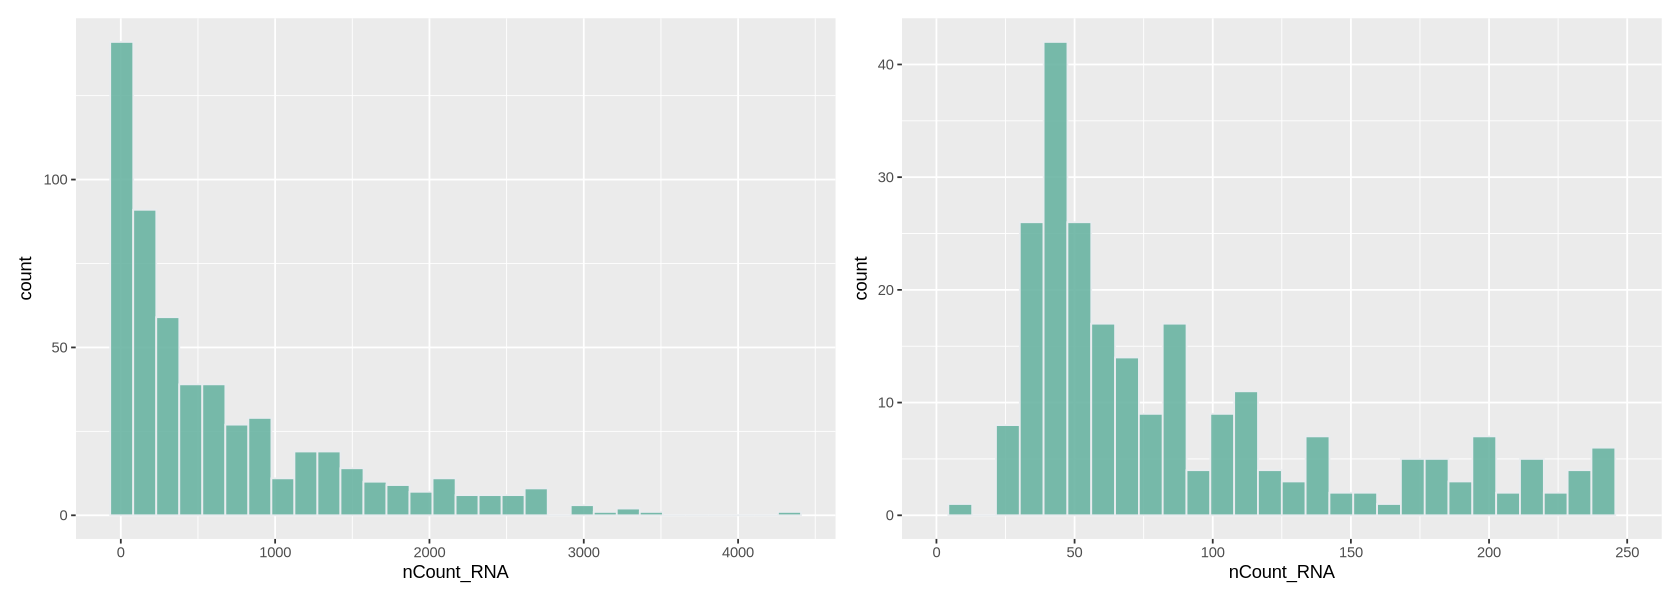

In [40]:
options(repr.plot.width=14, repr.plot.height=5)

plot1 <- ggplot(data@meta.data, aes(x=nCount_RNA)) + 
     geom_histogram(fill="#69b3a2", color="#e9ecef", alpha=0.9)

plot2 <- ggplot(data@meta.data, aes(x=nCount_RNA)) + 
     geom_histogram(fill="#69b3a2", color="#e9ecef", alpha=0.9) +
     xlim(0,250)

plot1 + plot2

#### Number of detected genes per cell

Here we work similarly to filter out cells based on how many genes are
detected ([Figure 8](#fig-genecounts)). The right-side plot is a zoom
into the histogram. It seems easy to set the thresholds at ~400 and
~7000 detected genes.

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
Warning message:
“Removed 258 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


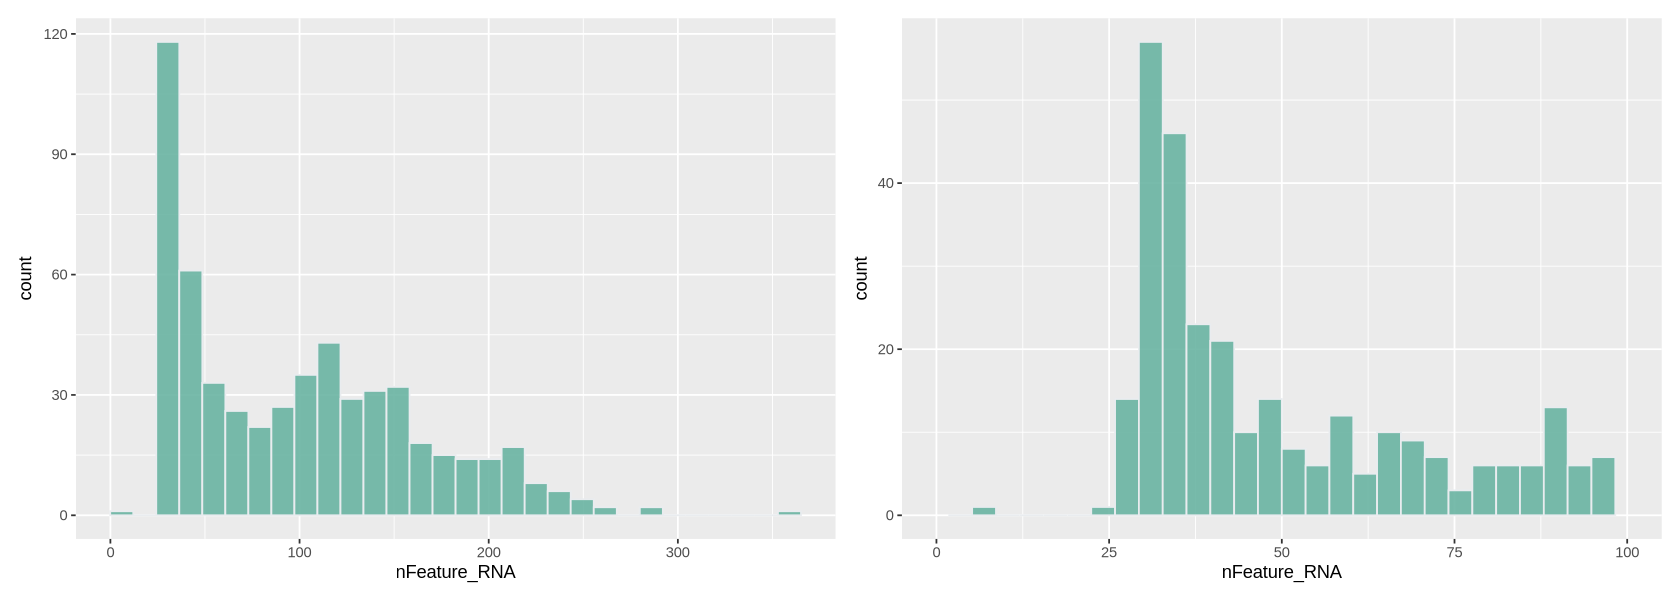

In [41]:
options(repr.plot.width=14, repr.plot.height=5)

plot1 <- ggplot(data@meta.data, aes(x=nFeature_RNA)) + 
     geom_histogram(fill="#69b3a2", color="#e9ecef", alpha=0.9)

plot2 <- ggplot(data@meta.data, aes(x=nFeature_RNA)) + 
     geom_histogram(fill="#69b3a2", color="#e9ecef", alpha=0.9) +
     xlim(0,100)


plot1 + plot2

#### Counts-Features relationship

In [Figure 10](#fig-gentra) below, we look at the plot of the number of
transcripts per cell vs the number of detected genes per cell. Usually,
those two measure grow simultaneously. At lower counts the relationship
is quite linear, then becomes a curve, typically bending in favour of
the number of transcripts per cell. You can see below that each dot
(representing a droplet) is coloured by percentage of mitochondria.
Droplets with a high percentage of mitochondrial genes also have very
low amount of transcripts and detected genes, **confirming that high
mitochondrial content is a measure of low quality**.

`geom_smooth()` using formula = 'y ~ x'


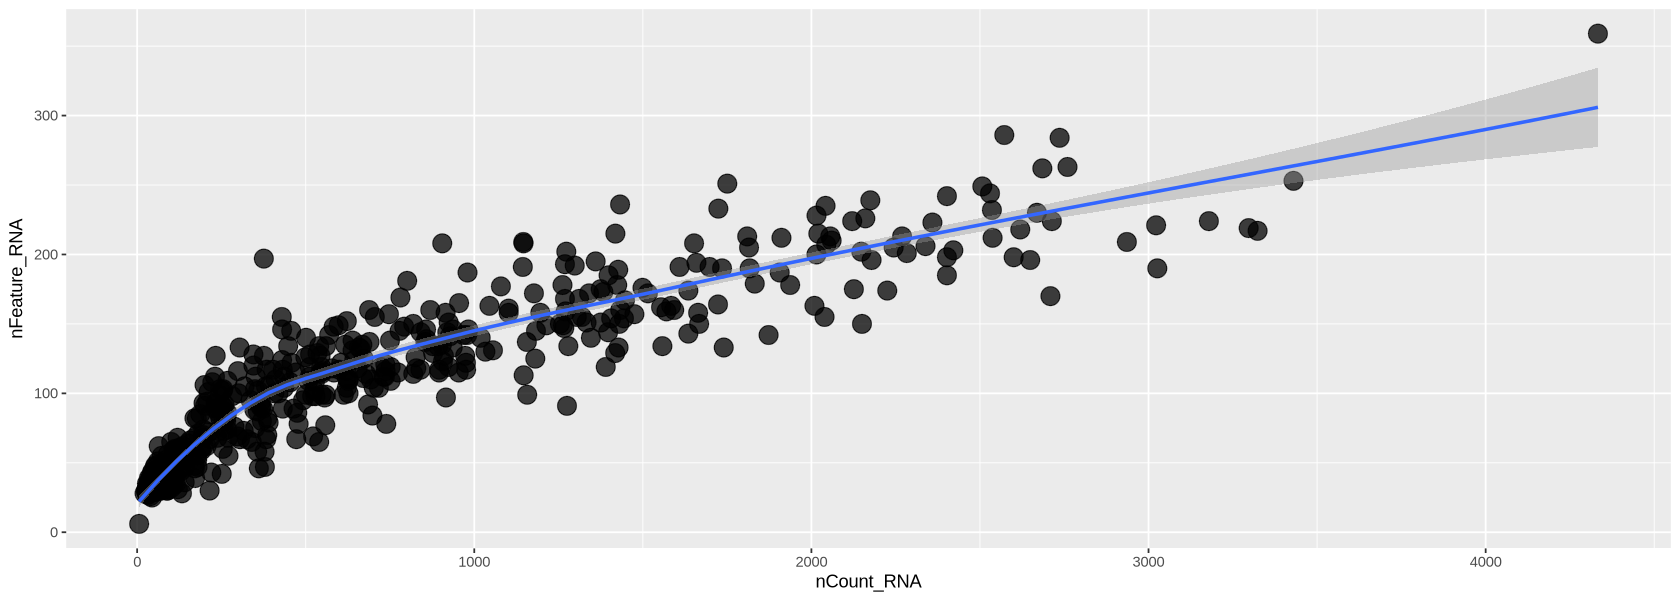

In [28]:
options(repr.plot.width=14, repr.plot.height=5)

meta <- data@meta.data %>% arrange(percent.mt)

plot1 <- ggplot( meta, aes(x=nCount_RNA, y=nFeature_RNA)) + 
         geom_point(alpha=0.75, size=5)+
         geom_smooth(se=TRUE, method="loess")

plot1

### Filtering with the chosen criteria

Here we use the command `subset` and impose the criteria we chose above
looking at the histograms. We set each criteria for keeping cells of
good quality using the names of the features in metadata. We print those
names to remember them.

In [57]:
cat("Meta data names:\n")
cat( names(data@meta.data), sep='; ' )

Meta data names:
orig.ident; nCount_RNA; nFeature_RNA

The filtered object is called `Control1_seurat_filt`

In [58]:
dataFilt <- subset(x = data, 
                                        subset = nCount_RNA > 50 &
                                                 nCount_RNA < 3000 &
                                                 nFeature_RNA > 35 & 
                                                 nFeature_RNA < 300)

cat("Filtered Genes and Cells: ")
cat( dim(data) - dim(dataFilt) )
cat("\nRemaining Genes and Cells: ")
cat( dim(dataFilt) )

Filtered Genes and Cells: 0 131
Remaining Genes and Cells: 1914 428

Now the transcripts vs genes can be seen in
[Figure 12](#fig-filtrelationship). The relationship is much more linear
than previously after the removal of extreme values for transcripts and
detected genes.

`geom_smooth()` using formula = 'y ~ x'


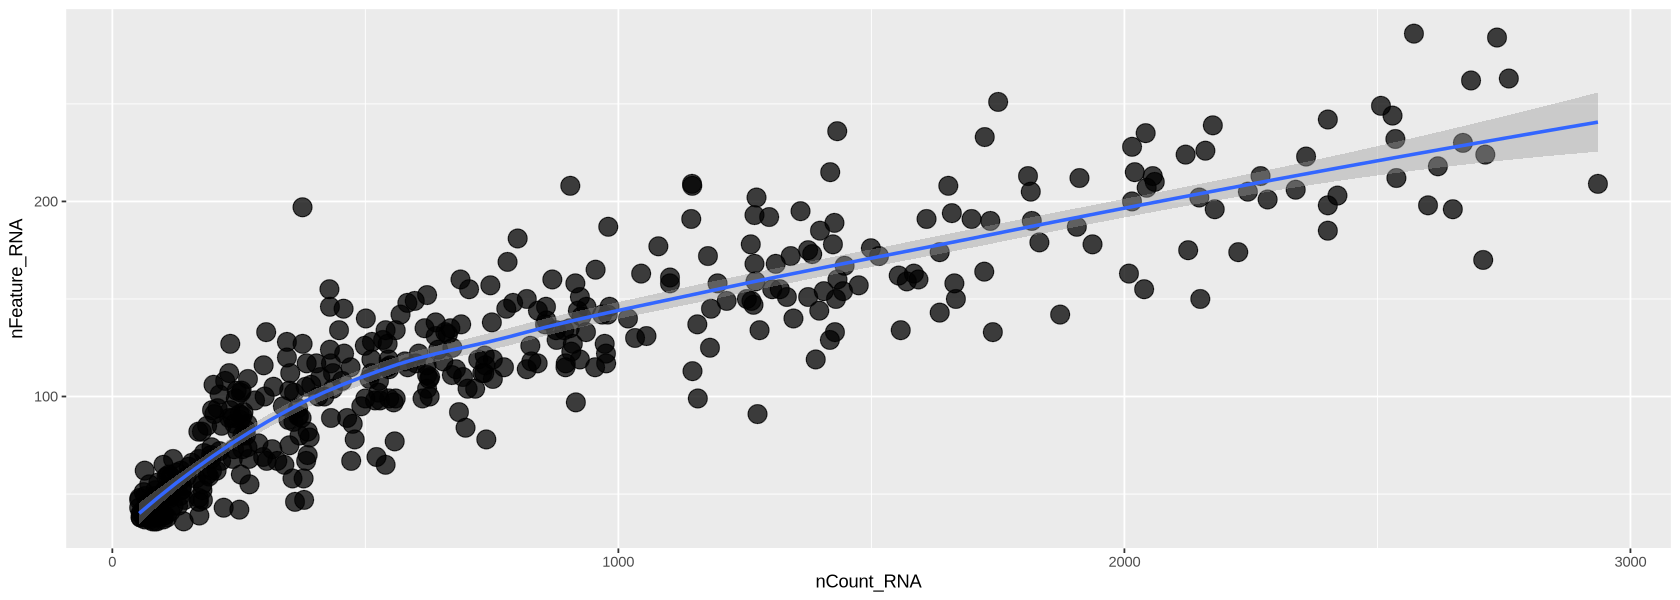

In [60]:
options(repr.plot.width=14, repr.plot.height=5)

plot1 <- ggplot( dataFilt@meta.data, aes(x=nCount_RNA, y=nFeature_RNA)) + 
         geom_point(alpha=0.75, size=5)+
         geom_smooth(se=TRUE, method="loess")

plot1

## Normalization

scRNA-seq data is **affected by highly variable RNA quantities and
qualities** across different cells. Furthermore, it is often subject to
**batch effects, sequencing depth differences, and other technical
biases** that can confound downstream analyses.

Normalization methods are used to **adjust for these technical
variations so that true biological differences between cells can be
accurately identified**.

Some commonly used normalization methods in scRNA-seq data include the
following:

-   **Total count normalization**: Normalizing the read counts to the
    total number of transcripts in each sample
-   **TPM (transcripts per million)** normalization: Normalizing the
    read counts to the total number of transcripts in each sample,
    scaled to a million
-   **Library size normalization:** Normalizing the read counts to the
    total number of reads or transcripts in each sample, adjusted for
    sequencing depth

All the above suffer from distorting some gene expressions. However, we use the TPM transformation together with the logarithm, as our dataset is small with a few reads, and newer methods require large datasets.

### Executing normalization

We run `SCtransform` normalization below. Here you can choose to
subsample some cells to do the normalization (`ncells` option): this is
**useful to avoid ending up waiting for a long time**. A few thousands
cells is enough.

You can also choose how many genes to consider for normalization
(`variable.features.n` option): in this case it is best to **use the
genes that vary the most their expression across cells**. We look at a
histogram ([Figure 14](#fig-hvg)) of the variance of each gene to choose
a threshold to identify highly-variable genes.

In [32]:
dataFilt

An object of class Seurat 
1914 features across 307 samples within 1 assay 
Active assay: RNA (1914 features, 0 variable features)
 1 layer present: counts

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
Warning message:
“Removed 177 rows containing non-finite outside the scale range (`stat_bin()`).”


Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


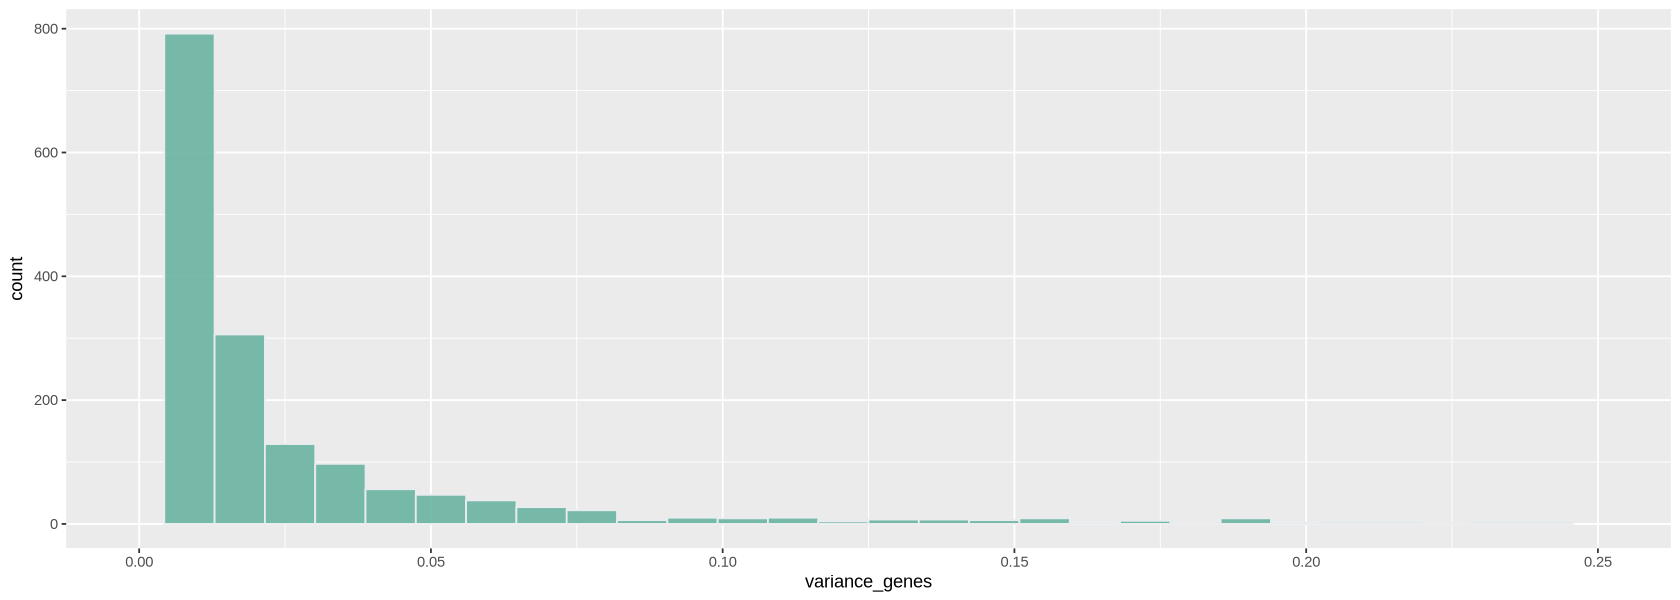

In [62]:
variance_genes <- apply(GetAssayData(object = dataFilt,
            assay = 'RNA',
            layer = 'counts'), 1, var)

options(repr.plot.width=14, repr.plot.height=5)

plot1 <- ggplot(data.frame(variance_genes), aes(variance_genes)) + 
     geom_histogram(fill="#69b3a2", color="#e9ecef", alpha=0.9) + xlim(0,.25)

plot1

In [63]:
highly_var_genes <- variance_genes > .25
cat("The total number of highly variable genes selected is: ")
cat(sum( highly_var_genes ))

The total number of highly variable genes selected is: 177

In [64]:
dataNorm <- NormalizeData(dataFilt, normalization.method = "LogNormalize")

Normalizing layer: counts



Normalized data is now in the object `dataNorm`. Notice the new layer. `data` contains rescaled+log-transformed data

In [65]:
dataNorm

An object of class Seurat 
1914 features across 428 samples within 1 assay 
Active assay: RNA (1914 features, 0 variable features)
 2 layers present: counts, data

In [66]:
dataNorm <- ScaleData(dataNorm)

Centering and scaling data matrix



### Visualizing the result

Now we plot the UMAP plot of the data to have a first impression of how
the data is structured (presence of clusters, how many, etc.). First of
all, we create a PCA plot, which tells us how many PCA components are of
relevance with the elbow plot of [Figure 15](#fig-elbow). In the elbow
plot, we see the variability of each component in descending order. Note
how, after a few rapidly descending components, there is an elbow. We
schoose a threshold just after the elbow (for example at 15), which
means those components will be used to calculate some other things of
relevance in the data, such as distance between cells and the UMAP
projection of [Figure 16](#fig-umap): specific commands using PCA allow
to choose the components, and we will set 10 with the option
`dims = 1:15`.

In [67]:
dataNorm <- FindVariableFeatures(dataNorm, nfeatures = sum( highly_var_genes ))

Finding variable features for layer counts



In [68]:
dataNorm <- RunPCA(object = dataNorm, verbose = FALSE, seed.use = 123)

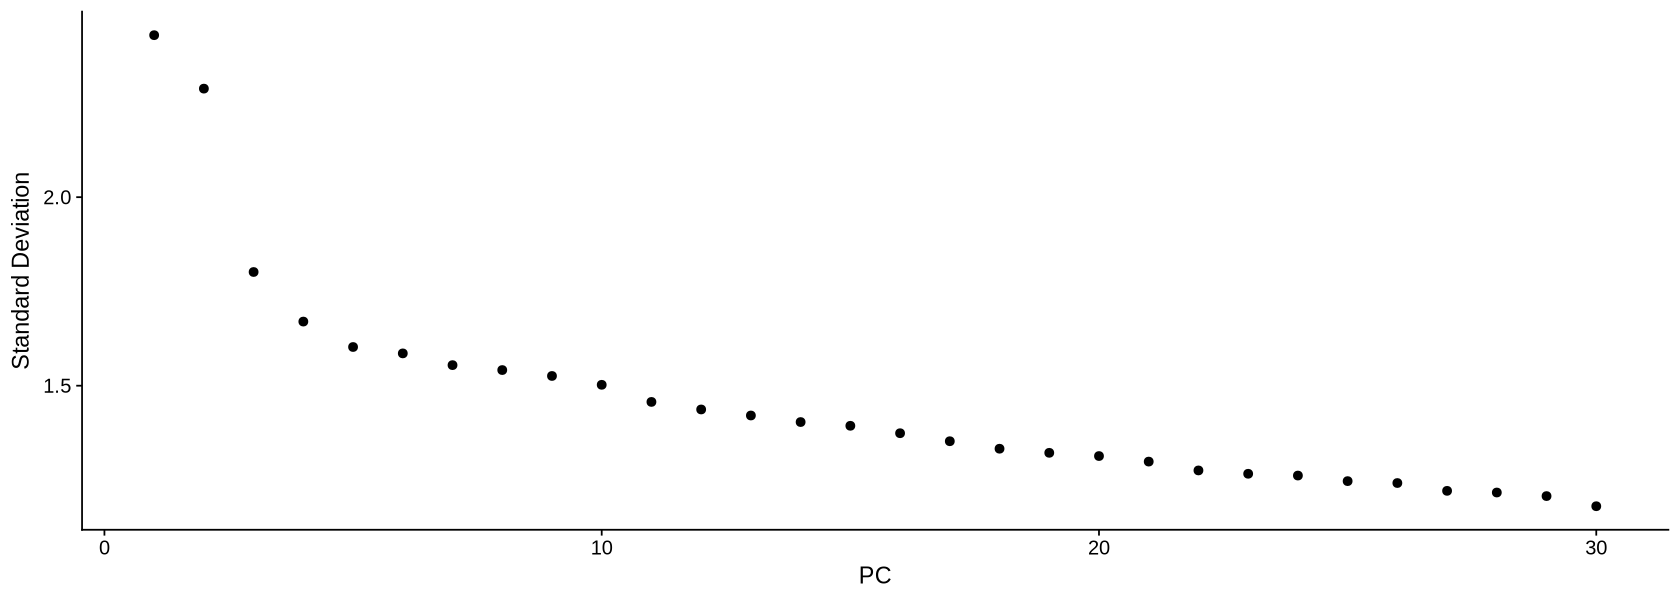

In [69]:
ElbowPlot(dataNorm, ndims = 30)

We calculate the projection using the UMAP algorithm (McInnes et al.
(2018), Becht et al. (2019)). The parameters `a` and `b` will change how
stretched and scattered the data looks like. When you do your own UMAP
projection, you can avoid setting `a` and `b`, and those will be chosen
automatically by the command.

In [76]:
dataNorm <- RunUMAP(object = dataNorm, 
                    a = .8, b=1,
                    dims = 1:8, 
                    verbose = FALSE, 
                    seed.use = 123)

In [Figure 16](#fig-umap) we can see the resulting projection. The
result looks pretty neat and structured (we can clearly see there are
various clusters).

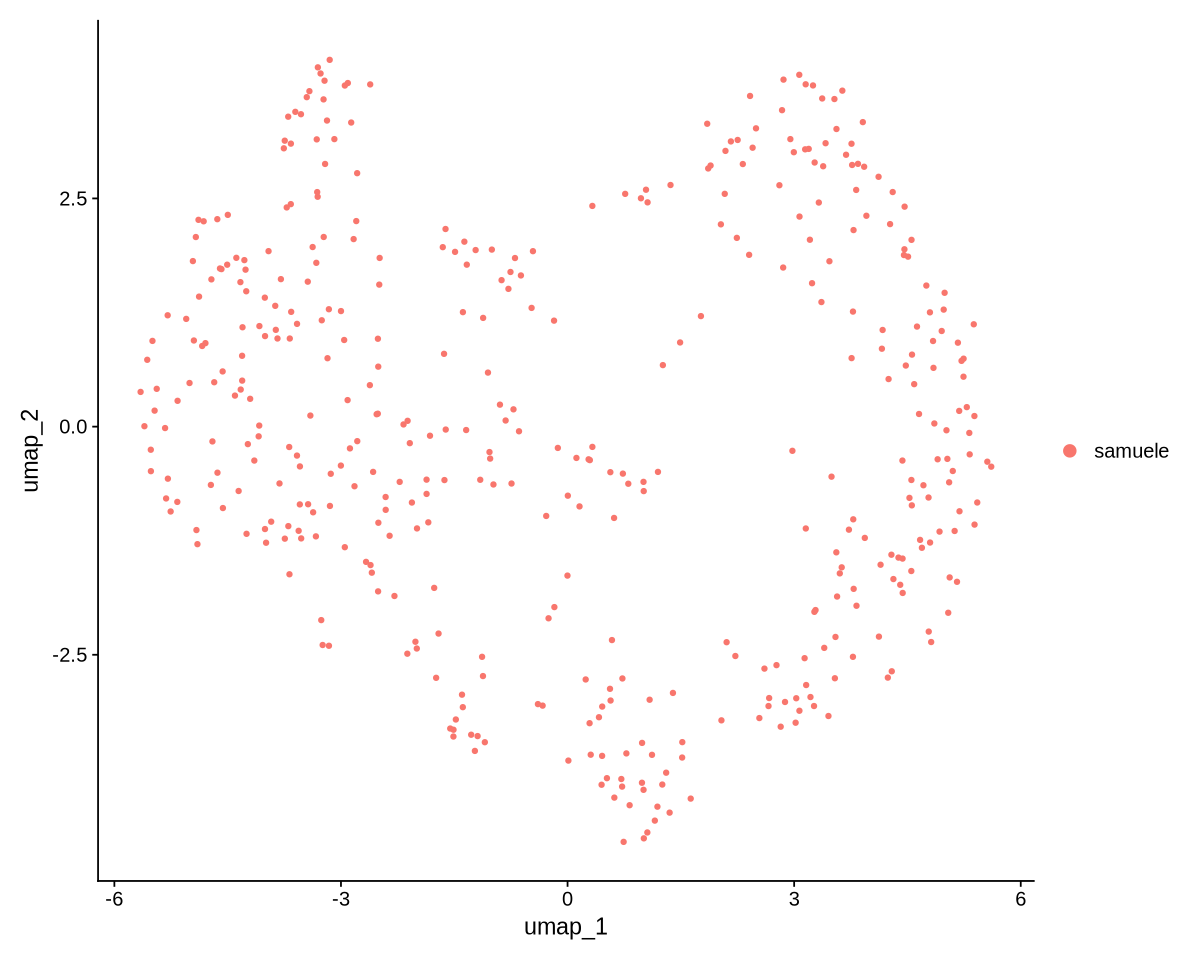

In [77]:
options(repr.plot.width=10, repr.plot.height=8)
UMAPPlot(object = dataNorm)

We save our data after all the filtering work!

In [78]:
save(dataNorm, file = "data.rds")